In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/retail-store-product-sales-simulation-dataset/RetailStoreProductSalesDataset.csv


In [2]:
import pandas as  pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = "/kaggle/input/retail-store-product-sales-simulation-dataset/RetailStoreProductSalesDataset.csv"
df = pd.read_csv(data)
df.head(5)

,Unnamed: 0,price,discount,promotion_intensity,footfall,ad_spend,competitor_price,stock_level,weather_index,customer_sentiment,return_rate
0,0,45.197454,5.514259,4.062653,277.017484,2559.073870,44.255411,1176.981397,7.442194,1.021762,0.067388
1,1,49.327512,6.572035,4.964657,250.760714,2536.417155,50.331704,1219.359497,6.759510,0.975142,0.082719
2,2,47.328457,6.972713,4.363191,263.130478,2552.952356,49.285996,1263.822738,5.941689,0.871567,0.061600
3,3,50.964538,4.808234,3.577988,297.603918,2605.398826,46.839936,1182.435378,8.517014,1.071300,0.052215
4,4,44.530213,8.180216,4.966638,208.931691,2432.485683,45.336500,1178.513263,8.422473,1.068515,0.057975


In [3]:
df.shape

(15000, 11)

In [4]:
corr_return_rate = df.corr()['return_rate'].sort_values(ascending = False)
corr_return_rate

return_rate            1.000000
ad_spend               0.124195
Unnamed: 0             0.055581
footfall               0.052372
stock_level            0.044732
discount              -0.047649
promotion_intensity   -0.062459
weather_index         -0.300116
competitor_price      -0.357296
price                 -0.366146
customer_sentiment    -0.673464
Name: return_rate, dtype: float64

In [5]:
data = df.drop(columns=['return_rate'])
y = df['return_rate']

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(data,y, test_size = 0.2,random_state=42)

In [7]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [8]:
import tensorflow
from tensorflow import keras
from keras import layers
from keras.layers import Dense,Dropout
from keras import Sequential

2026-01-24 09:02:17.706378: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769245337.964595      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769245338.038276      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769245338.631887      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769245338.631944      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769245338.631950      17 computation_placer.cc:177] computation placer alr

In [9]:
model = Sequential()
model.add(Dense(10, input_dim = 10,activation = 'relu',kernel_initializer = 'he_uniform'))
model.add(Dropout(0.2))
model.add(Dense(4,activation='relu',kernel_initializer = 'he_uniform'))
model.add(Dropout(0.2))
model.add(Dense(1,activation='linear',kernel_initializer = 'he_uniform'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-24 09:02:35.482139: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
model.get_weights()

[array([[-0.24939579, -0.6180357 , -0.16414553,  0.4244696 ,  0.17129815,
         -0.50005233, -0.32884085, -0.01005334, -0.2686575 , -0.6829265 ],
        [ 0.18847376,  0.323323  , -0.4776243 ,  0.04275006, -0.329208  ,
          0.3782053 ,  0.3283192 ,  0.2553463 ,  0.49561286,  0.5065255 ],
        [-0.7350281 , -0.39354306, -0.4196719 ,  0.6974516 , -0.497494  ,
          0.49599862, -0.76124   , -0.57255536, -0.6094271 ,  0.363302  ],
        [ 0.00253248, -0.6843963 ,  0.20971656,  0.41406214, -0.0636034 ,
         -0.32416072,  0.29640377, -0.61669254,  0.35988748, -0.45980412],
        [ 0.5914793 ,  0.04894269,  0.44923866, -0.65115553,  0.5309043 ,
         -0.6109618 , -0.00944221, -0.44439384, -0.73899424,  0.16444528],
        [ 0.38409865, -0.7542099 , -0.25862634,  0.6651161 ,  0.3200245 ,
          0.18164104, -0.611524  ,  0.3381617 , -0.57265216, -0.04695499],
        [-0.448321  , -0.16113567, -0.18191862, -0.10685319, -0.25886643,
          0.09447676, -0.3279215

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            44 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159 (636.00 B)

 Trainable params: 159 (636.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])
history = model.fit(X_train_scaled, y_train, epochs=20, batch_size=8,validation_split=0.2)

Epoch 1/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 5.4900 - mae: 1.2857 - val_loss: 0.0705 - val_mae: 0.2349
Epoch 2/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1136 - mae: 0.2401 - val_loss: 0.0087 - val_mae: 0.0786
Epoch 3/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0253 - mae: 0.0757 - val_loss: 0.0012 - val_mae: 0.0203
Epoch 4/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0048 - mae: 0.0276 - val_loss: 5.7970e-04 - val_mae: 0.0155
Epoch 5/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0027 - mae: 0.0198 - val_loss: 3.9440e-04 - val_mae: 0.0146
Epoch 6/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7.4518e-04 - mae: 0.0155 - val_loss: 3.5970e-04 - val_mae: 0.0144
Epoch 7/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.1472e-04 - mae: 0.0148 - val_loss: 3.4699e-04 - val_mae: 0.0143
Epoch 8/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.3324e-04 - mae: 0.0150 - val_loss: 3.2894e-04 - val_mae: 0.0142
Epoch 9/

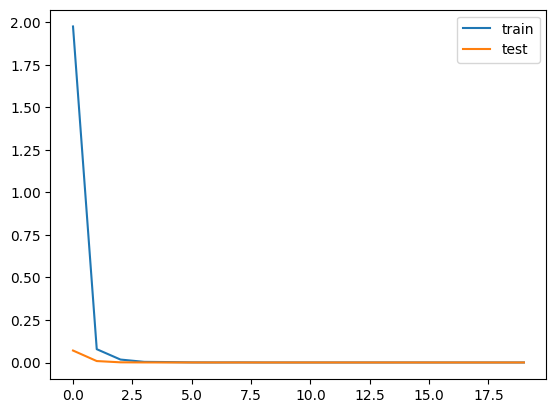

In [13]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

In [14]:
y_pred = model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [15]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mse

312760.75528006745

In [16]:
y_pred[0]

array([705.4687], dtype=float32)

In [17]:
y_test.iloc[0]

np.float64(0.0615395465074)